**DATA ACQUISITION**

In [ ]:
!pip install missingno
!pip install xgboost
!pip install tensorflow
!pip install -q shap
!pip install -q boto3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 803.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 94.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 71.6 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 109.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import requests
import zipfile
import missingno as msno
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [ ]:
# main_zip_url = "http://205.174.165.80/CICDataset/CIC-IDS-2017/Dataset/MachineLearningCSV.zip"
# main_zip_path = "data/MachineLearningCSV.zip"
# extract_dir = "data"
# csv_files_in_zip = [
#     "MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv",
#     "MachineLearningCVE/Tuesday-WorkingHours.pcap_ISCX.csv",
#     "MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv",
#     "MachineLearningCVE/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
#     "MachineLearningCVE/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
#     "MachineLearningCVE/Friday-WorkingHours-Morning.pcap_ISCX.csv",
#     "MachineLearningCVE/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
#     "MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"
# ]
# os.makedirs("data", exist_ok=True)

# if not os.path.exists(main_zip_path):
#     with requests.get(main_zip_url, stream=True) as r:
#         r.raise_for_status()
#         with open(main_zip_path, "wb") as f:
#             for chunk in r.iter_content(chunk_size=1024 * 1024):
#                 if chunk:
#                     f.write(chunk)

# with zipfile.ZipFile(main_zip_path, "r") as zip_ref:
#     for file in csv_files_in_zip:
#         zip_ref.extract(file, extract_dir)

In [ ]:
# The notebook had a commented-out section for downloading, but it was for a different dataset.
# The new data is available locally after downloading from Kaggle.

# main_zip_url = "http://205.174.165.80/CICDataset/CIC-IDS-2017/Dataset/MachineLearningCSV.zip"
# main_zip_path = "data/MachineLearningCSV.zip"
# extract_dir = "data"
# csv_files_in_zip = [
#     "MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv",
#     "MachineLearningCVE/Tuesday-WorkingHours.pcap_ISCX.csv",
#     "MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv",
#     "MachineLearningCVE/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
#     "MachineLearningCVE/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
#     "MachineLearningCVE/Friday-WorkingHours-Morning.pcap_ISCX.csv",
#     "MachineLearningCVE/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
#     "MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"
# ]
# os.makedirs("data", exist_ok=True)

# if not os.path.exists(main_zip_path):
#     with requests.get(main_zip_url, stream=True) as r:
#         r.raise_for_status()
#         with open(main_zip_path, "wb") as f:
#             for chunk in r.iter_content(chunk_size=1024 * 1024):
#                 if chunk:
#                     f.write(chunk)

# with zipfile.ZipFile(main_zip_path, "r") as zip_ref:
#     for file in csv_files_in_zip:
#         zip_ref.extract(file, extract_dir)

**Merging the datasets**

In [ ]:
import os
import sys

kaggle_json_path = '/content/kaggle.json'
kaggle_dir = os.path.expanduser('~/.kaggle')
target_kaggle_json_path = os.path.join(kaggle_dir, 'kaggle.json')

# Create a .kaggle directory if it doesn't exist
os.makedirs(kaggle_dir, exist_ok=True)

if os.path.exists(kaggle_json_path):
    # Move the uploaded kaggle.json file to the correct directory
    !mv {kaggle_json_path} {target_kaggle_json_path}

    # Set permissions for the kaggle.json file
    !chmod 600 {target_kaggle_json_path}
    print(f"'{kaggle_json_path}' moved to '{target_kaggle_json_path}' and permissions set.")
else:
    print("WARNING: 'kaggle.json' not found in the current working directory.")
    print("Please upload your kaggle.json file to the Colab environment using the 'Files' tab (folder icon on the left sidebar).")
    print("After uploading, please re-run this cell and the subsequent cells for Kaggle dataset download.")
    # The 'kaggle' library authentication will fail in the next cell if kaggle.json is not present.
    # We let the pip install run as it's independent.




'/content/kaggle.json' moved to '/root/.kaggle/kaggle.json' and permissions set.


In [ ]:
import zipfile

# Dataset name from the URL: chethuhn/network-intrusion-dataset
dataset_name = "chethuhn/network-intrusion-dataset"

# Download the dataset from Kaggle
# First, ensure Kaggle library is properly configured and authenticated.
!kaggle datasets download -d {dataset_name}

# Define the directory where the dataset will be extracted
extract_dir = "network-intrusion-dataset"
os.makedirs(extract_dir, exist_ok=True)

# Unzip the dataset. The downloaded file will be named 'network-intrusion-dataset.zip'
zip_file_path = f"{dataset_name.split('/')[-1]}.zip"

# Check if the zip file exists before trying to open it
if os.path.exists(zip_file_path):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

    print(f"Dataset extracted to '{extract_dir}/")
    # Remove the zip file after extraction to save space
    os.remove(zip_file_path)
else:
    print(f"Error: Zip file '{zip_file_path}' not found. Please ensure it's uploaded or downloaded.")

Dataset URL: https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset
License(s): CC0-1.0
100% 230M/230M [00:01<00:00, 164MB/s]

Dataset extracted to 'network-intrusion-dataset/


In [ ]:
input_dir = "network-intrusion-dataset"
output_csv = "merged_network_intrusion_dataset.csv"

csv_files = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"
]

In [ ]:
first_chunk = True

for file in csv_files:
    file_path = os.path.join(input_dir, file)
    for chunk in pd.read_csv(file_path, chunksize=100_000, low_memory=False):
        chunk.replace([np.inf, -np.inf], np.nan, inplace=True)
        chunk.dropna(inplace=True)
        chunk.to_csv(
            output_csv,
            mode="w" if first_chunk else "a",
            index=False,
            header=first_chunk
        )
        first_chunk = False

In [ ]:
data = pd.read_csv(output_csv)

EDA

In [ ]:
data.columns

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [ ]:
data.shape

(2827876, 79)

In [ ]:
import numpy as np
import pandas as pd

def amputate_data(df, label_col, missing_rate=0.2, random_state=42):
    np.random.seed(random_state)
    df_a = df.copy()
    cols = df_a.drop(columns=[label_col]).select_dtypes(include=[np.number]).columns
    mask = np.random.rand(len(df_a), len(cols)) < missing_rate
    df_a.loc[:, cols] = df_a[cols].mask(mask)
    return df_a

df_amputated = amputate_data(data, " Label", 0.2)

/tmp/ipykernel_1489/4258119413.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[49188. 49188. 49188. ... 61375. 61323. 61326.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_a.loc[:, cols] = df_a[cols].mask(mask)
/tmp/ipykernel_1489/4258119413.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 4. nan  1. ... 75. 48. 68.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_a.loc[:, cols] = df_a[cols].mask(mask)
/tmp/ipykernel_1489/4258119413.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[2. 2. 2. ... 1. 2. 1.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_a.loc[:, cols] = df_a[cols].mask(mask)
/tmp/ipykernel_1489/4258119413.py:9: 

In [ ]:
#removing duplicates
duplicates = data[data.duplicated()]
print("No of duplicates:",len(duplicates))
print("After removing duplicates")
data.drop_duplicates(inplace = True)
data.shape

No of duplicates: 307078
After removing duplicates


(2520798, 79)

In [ ]:
numeric_cols = data.select_dtypes(include=[np.number]).columns
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())

categorical_cols = data.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    if not data[col].mode().empty:
        data[col] = data[col].fillna(data[col].mode()[0])

print(data.isna().sum())

 Destination Port              0
 Flow Duration                 0
 Total Fwd Packets             0
 Total Backward Packets        0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
 Idle Std                      0
 Idle Max                      0
 Idle Min                      0
 Label                         0
Length: 79, dtype: int64


**Analysing the attacks**

In [ ]:
data[' Label'].value_counts()

,count
Label,
BENIGN,2095057
DoS Hulk,172846
DDoS,128014
PortScan,90694
DoS GoldenEye,10286
FTP-Patator,5931
DoS slowloris,5385
DoS Slowhttptest,5228
SSH-Patator,3219


In [ ]:
#maping lable to the attack types
types = {
    'BENIGN': 'BENIGN',
    'DDoS': 'DDoS',
    'DoS Hulk': 'DoS',
    'DoS GoldenEye': 'DoS',
    'DoS slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    'PortScan': 'Port Scan',
    'FTP-Patator': 'Brute Force',
    'SSH-Patator': 'Brute Force',
    'Bot': 'Bot',
    'Web Attack � Brute Force': 'Web Attack',
    'Web Attack � XSS': 'Web Attack',
    'Web Attack � Sql Injection': 'Web Attack',
    'Infiltration': 'Infiltration',
    'Heartbleed': 'Heartbleed'
}
data['types'] = data[' Label'].map(types)

In [ ]:
data[' Label'].unique()

array(['BENIGN', 'FTP-Patator', 'SSH-Patator', 'DoS slowloris',
       'DoS Slowhttptest', 'DoS Hulk', 'DoS GoldenEye', 'Heartbleed',
       'Web Attack � Brute Force', 'Web Attack � XSS',
       'Web Attack � Sql Injection', 'Infiltration', 'Bot', 'PortScan',
       'DDoS'], dtype=object)

In [ ]:
selected_types = ['BENIGN', 'DoS', 'DDoS']
data = data[data['types'].isin(selected_types)].copy()

print("Class distribution after filtering:")
print(data['types'].value_counts())

Class distribution after filtering:
types
BENIGN    2095057
DoS        193745
DDoS       128014
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['target'] = le.fit_transform(data['types'])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'BENIGN': np.int64(0), 'DDoS': np.int64(1), 'DoS': np.int64(2)}


In [ ]:
# cols_to_drop = [' Label', 'types', 'Attacknum']
# data = data.drop(columns=[c for c in cols_to_drop if c in data.columns], errors='ignore')

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['target'] = le.fit_transform(data['types'])
encoded = data['target'].unique()
print(encoded)
for val in encoded:
    print(val,le.inverse_transform([val])[0])

[0 2 1]
0 BENIGN
2 DoS
1 DDoS


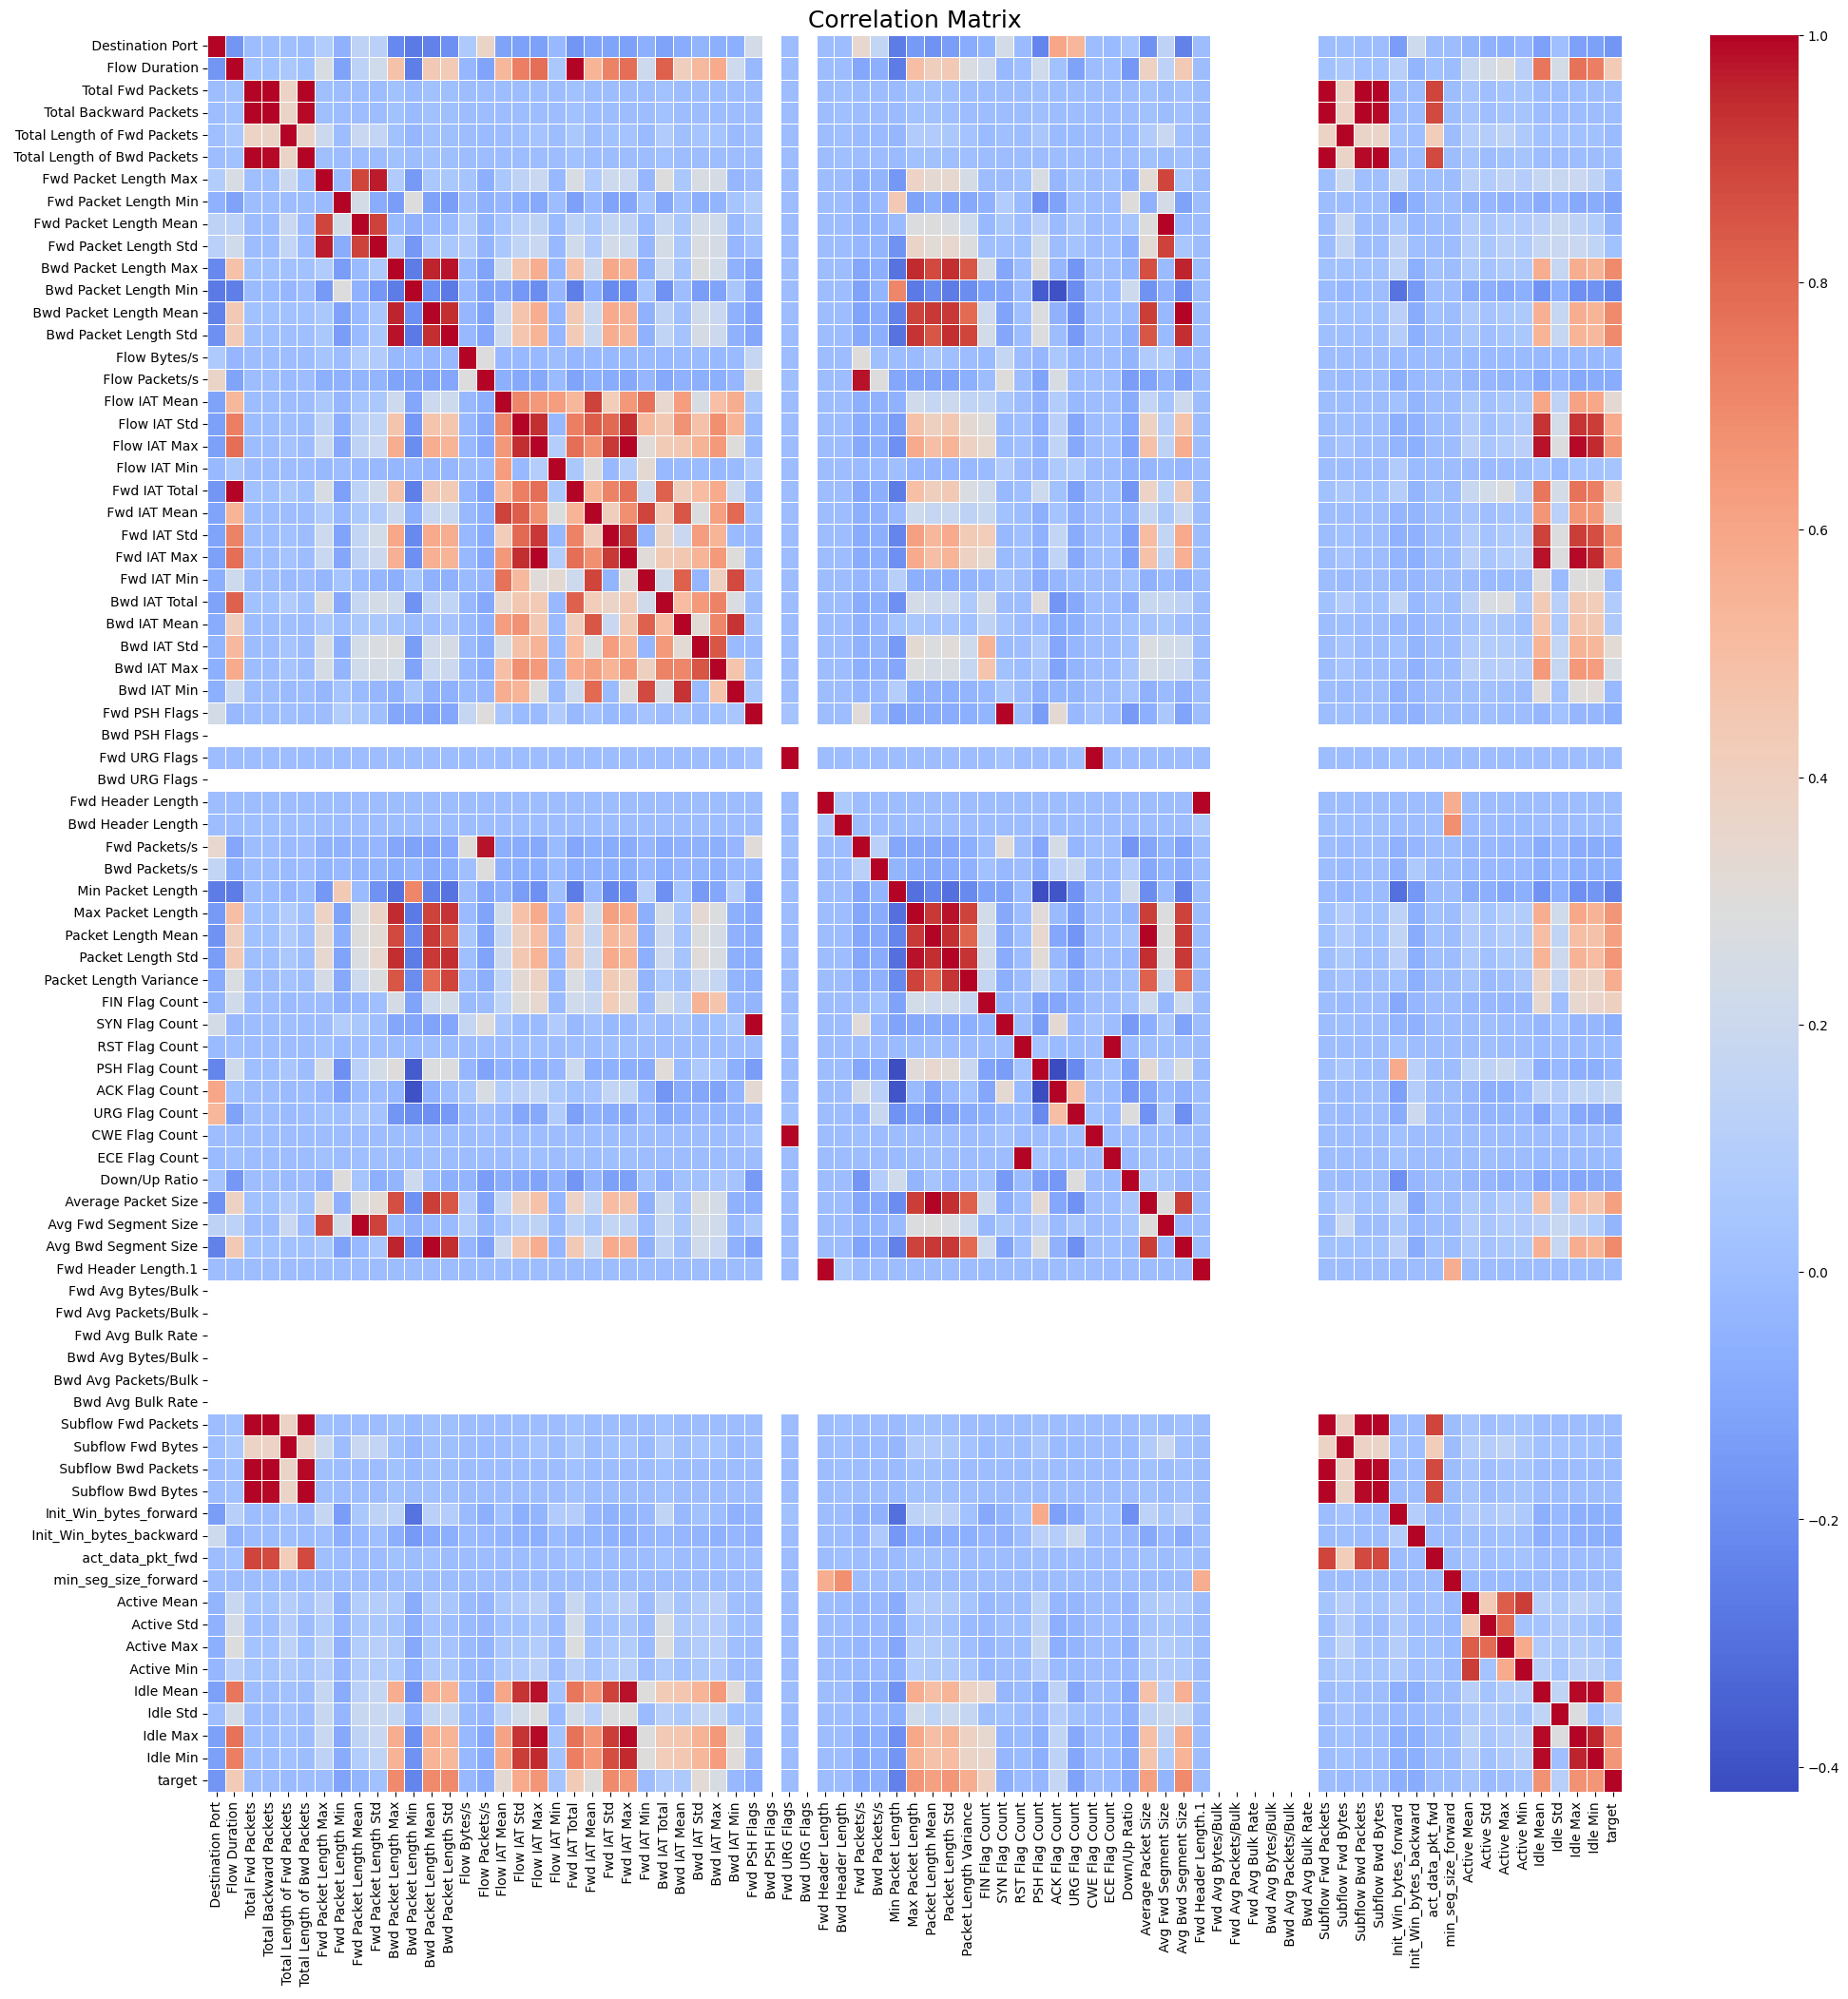

In [ ]:
fig, ax = plt.subplots(figsize = (24, 24))
corr = data.corr(numeric_only = True).round(2)
sns.heatmap(corr, cmap = 'coolwarm', annot = False, linewidth = 0.5)
plt.title('Correlation Matrix', fontsize = 18)
plt.show()

In [ ]:
# Positive correlation features for 'Attack Number'
pos_corr_features = corr['target'][(corr['target'] > 0) & (corr['target'] < 1)].index.tolist()

print("Features with positive correlation with 'target':\n")
for i, feature in enumerate(pos_corr_features, start = 1):
    corr_value = corr.loc[feature, 'target']
    print('{:<3} {:<18} :{}'.format(f'{i}.', feature, corr_value))

Features with positive correlation with 'target':

1.   Flow Duration     :0.43
2.   Fwd Packet Length Std :0.02
3.  Bwd Packet Length Max :0.7
4.   Bwd Packet Length Mean :0.7
5.   Bwd Packet Length Std :0.7
6.   Flow IAT Mean     :0.33
7.   Flow IAT Std      :0.58
8.   Flow IAT Max      :0.66
9.   Flow IAT Min      :0.04
10. Fwd IAT Total      :0.43
11.  Fwd IAT Mean      :0.3
12.  Fwd IAT Std       :0.7
13.  Fwd IAT Max       :0.66
14. Bwd IAT Total      :0.08
15.  Bwd IAT Mean      :0.07
16.  Bwd IAT Std       :0.32
17.  Bwd IAT Max       :0.26
18.  Max Packet Length :0.66
19.  Packet Length Mean :0.62
20.  Packet Length Std :0.66
21.  Packet Length Variance :0.57
22. FIN Flag Count     :0.4
23.  ACK Flag Count    :0.17
24.  Average Packet Size :0.62
25.  Avg Bwd Segment Size :0.7
26. Active Mean        :0.04
27.  Active Max        :0.01
28.  Active Min        :0.04
29. Idle Mean          :0.67
30.  Idle Std          :0.11
31.  Idle Max          :0.67
32.  Idle Min          :0.66


In [ ]:
print(f'Number of considerable important features: {len(pos_corr_features)}')

Number of considerable important features: 32


In [ ]:
# Checking for columns with zero standard deviation
std = data.std(numeric_only = True)
zero_std_cols = std[std == 0].index.tolist()
zero_std_cols

[' Bwd PSH Flags',
 ' Bwd URG Flags',
 'Fwd Avg Bytes/Bulk',
 ' Fwd Avg Packets/Bulk',
 ' Fwd Avg Bulk Rate',
 ' Bwd Avg Bytes/Bulk',
 ' Bwd Avg Packets/Bulk',
 'Bwd Avg Bulk Rate']

/tmp/ipykernel_1489/362956670.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = 'types', data = attacks, palette = 'pastel', order = attacks['types'].value_counts().index)


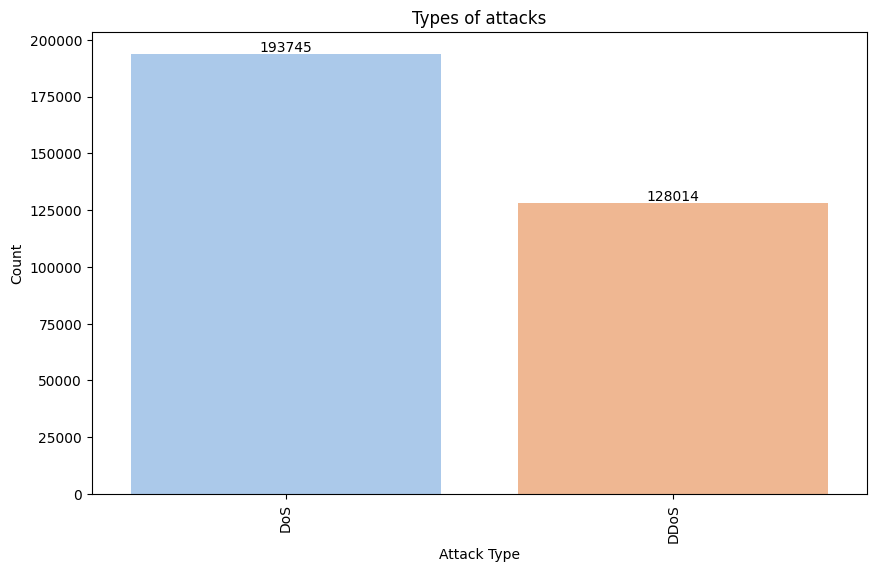

In [ ]:
attacks = data.loc[data['types'] != 'BENIGN']

plt.figure(figsize = (10, 6))
ax = sns.countplot(x = 'types', data = attacks, palette = 'pastel', order = attacks['types'].value_counts().index)
plt.title('Types of attacks')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation = 90)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2, p.get_height() + 1000), ha = 'center')

plt.show()

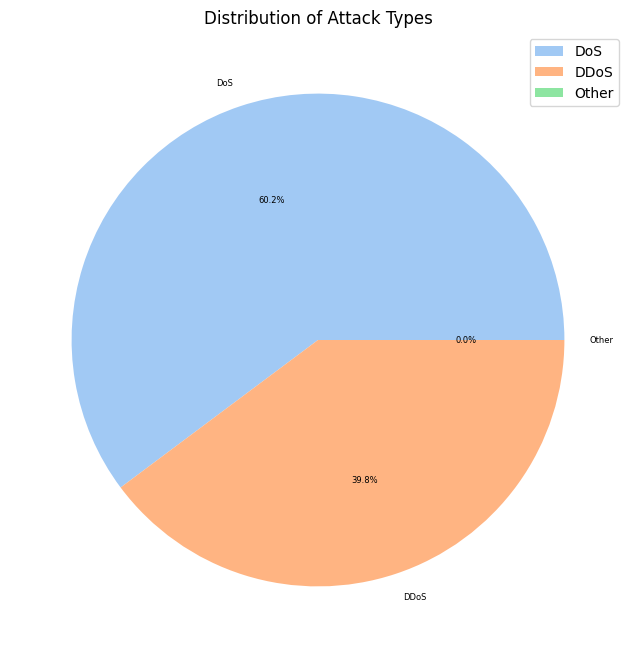

In [ ]:
attack_counts = attacks['types'].value_counts()
threshold = 0.005
percentages = attack_counts / attack_counts.sum()
small_slices = percentages[percentages < threshold].index.tolist()
attack_counts['Other'] = attack_counts[small_slices].sum()
attack_counts.drop(small_slices, inplace = True)

sns.set_palette('pastel')
plt.figure(figsize = (8, 8))
plt.pie(attack_counts.values, labels = attack_counts.index, autopct = '%1.1f%%', textprops={'fontsize': 6})
plt.title('Distribution of Attack Types')
plt.legend(attack_counts.index, loc = 'best')
plt.show()

In [ ]:
# For improving performance and reduce memory-related errors
old_memory_usage = data.memory_usage().sum() / 1024 ** 2
print(f'Initial memory usage: {old_memory_usage:.2f} MB')
for col in data.columns:
    col_type = data[col].dtype
    if col_type != object:
        c_min = data[col].min()
        c_max = data[col].max()
        # Downcasting float64 to float32
        if str(col_type).find('float') >= 0 and c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
            data[col] = data[col].astype(np.float32)

        # Downcasting int64 to int32
        elif str(col_type).find('int') >= 0 and c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
            data[col] = data[col].astype(np.int32)

new_memory_usage = data.memory_usage().sum() / 1024 ** 2
print(f"Final memory usage: {new_memory_usage:.2f} MB")

Initial memory usage: 1511.99 MB
Final memory usage: 802.09 MB


In [ ]:
print(f'Reduced memory usage: {1 - (new_memory_usage / old_memory_usage):.2%}')

Reduced memory usage: 46.95%


In [ ]:
data.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,target
count,2.416816e+06,2.416816e+06,2.416816e+06,2.416816e+06,2.416816e+06,2.416816e+06,2.416816e+06,2.416816e+06,2.416816e+06,2.416816e+06,...,2.416816e+06,2.416816e+06,2.416816e+06,2.416816e+06,2.416816e+06,2416816.0,2.416816e+06,2.416816e+06,2.416816e+06,2.416816e+06
mean,8.730102e+03,1.726228e+07,1.060642e+01,1.193977e+01,6.261230e+02,1.888409e+04,2.398920e+02,1.999055e+01,6.594695e+01,8.033064e+01,...,-3.216212e+03,9.545371e+04,4.815359e+04,1.793305e+05,6.823366e+04,9733460.0,5.899966e+05,1.017808e+07,9.269725e+06,2.132988e-01
std,1.922512e+04,3.581817e+07,8.112807e+02,1.079389e+03,1.031342e+04,2.449169e+06,7.680587e+02,6.197100e+01,1.985429e+02,3.023405e+02,...,1.174231e+06,7.001929e+05,4.248867e+05,1.107138e+06,6.234764e+05,25294906.0,4.976123e+06,2.607597e+07,2.502880e+07,5.728293e-01
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,2.390000e+02,2.000000e+00,1.000000e+00,2.600000e+01,6.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,6.035100e+04,2.000000e+00,2.000000e+00,6.800000e+01,1.660000e+02,4.200000e+01,6.000000e+00,3.800000e+01,0.000000e+00,...,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,5.504725e+06,6.000000e+00,5.000000e+00,3.470000e+02,1.583000e+03,2.270000e+02,3.800000e+01,5.300000e+01,7.868654e+01,...,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,4.672000e+03,7.125597e+03,...,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,120000000.0,7.690000e+07,1.200000e+08,1.200000e+08,2.000000e+00


In [ ]:
cols_to_drop = [' Label', 'types']
data = data.drop(columns=[c for c in cols_to_drop if c in data.columns], errors='ignore')

In [ ]:
num_unique = data.nunique()
one_variable = num_unique[num_unique == 1]
not_one_variable = num_unique[num_unique > 1].index
dropped_cols = one_variable.index
data = data[not_one_variable]

print('Dropped columns:')
dropped_cols

Dropped columns:


Index([' Bwd PSH Flags', ' Bwd URG Flags', 'Fwd Avg Bytes/Bulk',
       ' Fwd Avg Packets/Bulk', ' Fwd Avg Bulk Rate', ' Bwd Avg Bytes/Bulk',
       ' Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate'],
      dtype='object')

In [ ]:
data.shape

(2416816, 71)

In [ ]:
data.columns

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Fwd URG Flags',
       ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s',
       ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length',
       ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance',
       'FIN Flag Count', ' SYN Flag Count', 

In [ ]:
from sklearn.preprocessing import StandardScaler

features = data.drop('target', axis = 1)
attacks = data['target']

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [ ]:
from sklearn.decomposition import IncrementalPCA

size = len(features.columns) // 2
ipca = IncrementalPCA(n_components = size, batch_size = 500)
for batch in np.array_split(scaled_features, len(features) // 500):
    ipca.partial_fit(batch)

print(f'information retained: {sum(ipca.explained_variance_ratio_):.2%}')

information retained: 99.30%


In [ ]:
transformed_features = ipca.transform(scaled_features)
new_data = pd.DataFrame(transformed_features, columns = [f'PC{i+1}' for i in range(size)])
new_data['target'] = attacks.values

In [ ]:
new_data

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35,target
0,-2.418156,-0.055320,0.567971,0.728692,3.671444,0.251658,-0.013047,-0.203615,-0.363623,1.009867,...,-0.047955,-0.403215,1.433278,-0.120005,0.232982,0.001551,0.002553,0.036473,-0.011843,0
1,-2.944232,-0.070473,0.902040,1.756103,8.665891,0.587025,-0.039482,1.258077,2.086264,-2.542179,...,0.179943,-2.311466,2.079656,-0.659262,0.569154,0.031591,0.000740,0.136335,-0.174579,0
2,-2.477501,-0.057047,0.605977,0.844920,4.231767,0.287153,-0.016158,-0.043016,-0.090992,0.619129,...,-0.023015,-0.603426,1.506345,-0.176649,0.267755,0.004624,0.002361,0.047199,-0.030018,0
3,-2.945125,-0.070516,0.902928,1.758174,8.671276,0.585257,-0.039656,1.256266,2.086686,-2.538245,...,0.179561,-2.299650,2.080903,-0.655988,0.566574,0.031327,0.000749,0.135965,-0.174672,0
4,-1.522249,0.088267,-0.535900,0.315963,-0.549174,0.758827,0.097124,0.668957,-1.204653,-0.657629,...,-0.639860,0.199678,0.876945,-0.162707,-0.177696,-0.027624,0.000847,-0.060417,-0.013561,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2416811,-2.330092,-0.048866,0.473144,0.453920,2.154107,-0.121757,-0.020066,-0.821728,-1.059926,2.583286,...,0.100038,0.686511,0.789768,0.301058,-0.162496,-0.026030,0.001736,0.001337,-0.014069,0
2416812,-2.327025,-0.048765,0.471545,0.450592,2.133794,-0.122746,-0.019897,-0.823366,-1.064414,2.586215,...,0.103415,0.686931,0.790227,0.302137,-0.163679,-0.026130,0.001740,0.000850,-0.014261,0
2416813,-2.326335,-0.048743,0.471185,0.449821,2.129223,-0.122956,-0.019859,-0.823722,-1.065397,2.586821,...,0.104151,0.686874,0.790331,0.302325,-0.163901,-0.026149,0.001740,0.000743,-0.014300,0
2416814,-2.156282,-0.041986,0.352921,0.269844,1.779266,0.307616,0.006186,-0.311756,-0.725438,0.850354,...,-0.186271,1.765182,-0.843270,0.359318,-0.266319,-0.017878,0.002083,-0.084980,0.022852,0


In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
normal_traffic = new_data.loc[new_data['target'] == 0]
intrusions = new_data.loc[new_data['target'] != 0]

normal_traffic = normal_traffic.sample(n = len(intrusions), replace = False)

ids_data = pd.concat([intrusions, normal_traffic])
ids_data['target'] = np.where((ids_data['target'] == 0), 0, 1)
bc_data = ids_data.sample(n = 15000)

print(bc_data['target'].value_counts())

target
0    7522
1    7478
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_bc = bc_data.drop('target', axis = 1)
y_bc = bc_data['target']

X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(X_bc, y_bc, test_size = 0.25, random_state = 0)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr1 = LogisticRegression(max_iter = 10000, C = 0.1, random_state = 0, solver = 'saga')
lr1.fit(X_train_bc, y_train_bc)
cv_lr1 = cross_val_score(lr1, X_train_bc, y_train_bc, cv = 5)

y_pred_lr1 = lr1.predict(X_test_bc)
y_prob_lr1 = lr1.predict_proba(X_test_bc)[:, 1]
acc_lr1 = accuracy_score(y_test_bc, y_pred_lr1)
prec_lr1 = precision_score(y_test_bc, y_pred_lr1)
rec_lr1 = recall_score(y_test_bc, y_pred_lr1)
f1_lr1 = f1_score(y_test_bc, y_pred_lr1)
auc_lr1 = roc_auc_score(y_test_bc, y_prob_lr1)

print('Logistic regression Model 1')
print(f'\nCross-validation scores:', ', '.join(map(str, cv_lr1)))
print(f'\nMean cross-validation score: {cv_lr1.mean()}')
print(f'\n Accuracy of this model:{acc_lr1}')

Logistic regression Model 1

Cross-validation scores: 0.9697777777777777, 0.9662222222222222, 0.9666666666666667, 0.9702222222222222, 0.9555555555555556

Mean cross-validation score: 0.9656888888888888

 Accuracy of this model:0.9669333333333333


In [ ]:
lr2 = LogisticRegression(max_iter = 15000, solver = 'sag', C = 100, random_state = 0)
lr2.fit(X_train_bc, y_train_bc)

cv_lr2 = cross_val_score(lr2, X_train_bc, y_train_bc, cv = 5)
y_pred_lr2 = lr2.predict(X_test_bc)
y_prob_lr2 = lr2.predict_proba(X_test_bc)[:, 1]
acc_lr2 = accuracy_score(y_test_bc, y_pred_lr2)
prec_lr2 = precision_score(y_test_bc, y_pred_lr2)
rec_lr2 = recall_score(y_test_bc, y_pred_lr2)
f1_lr2 = f1_score(y_test_bc, y_pred_lr2)
auc_lr2 = roc_auc_score(y_test_bc, y_prob_lr2)

print('Logistic regression Model 2')
print(f'\nCross-validation scores:', ', '.join(map(str, cv_lr2)))
print(f'\nMean cross-validation score: {cv_lr2.mean()}')
print(f'\n Accuracy of this model:{acc_lr2}')

Logistic regression Model 2

Cross-validation scores: 0.9742222222222222, 0.9675555555555555, 0.9688888888888889, 0.9711111111111111, 0.9622222222222222

Mean cross-validation score: 0.9688000000000001

 Accuracy of this model:0.9701333333333333


# creating the balanced dataset for training #

In [ ]:
new_data['target'].value_counts()

,count
target,
0,2095057
2,193745
1,128014


In [ ]:
class_counts = new_data['target'].value_counts()
selected_classes = class_counts[class_counts > 1950]
class_names = selected_classes.index
selected = new_data[new_data['target'].isin(class_names)]

dfs = []
for name in class_names:
  df = selected[selected['target'] == name]
  df = df.sample(n = 9000, random_state = 0)

  dfs.append(df)

df = pd.concat(dfs, ignore_index = True)
df['target'].value_counts()

,count
target,
0,9000
2,9000
1,9000


In [ ]:
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

X = df.drop('target', axis=1)
y = df['target']

smote = SMOTE(sampling_strategy='auto', random_state=0)
X_upsampled, y_upsampled = smote.fit_resample(X, y)

blnc_data = pd.DataFrame(X_upsampled)
blnc_data['target'] = y_upsampled
blnc_data = blnc_data.sample(frac=1)

blnc_data['target'].value_counts()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 9.1 MB/s eta 0:00:00


,count
target,
1,9000
2,9000
0,9000


In [ ]:
features = blnc_data.drop('target', axis = 1)
labels = blnc_data['target']

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size = 0.25, random_state = 0)

#Random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators = 15, max_depth = 8, max_features = 20, random_state = 0)
rf.fit(X_train, y_train)

cv_rf = cross_val_score(rf, X_train, y_train, cv = 5)
print('Random Forest Model')
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, average='weighted')
rec_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
auc_rf = roc_auc_score(
    y_test,
    y_prob_rf,
    multi_class='ovr',
    average='weighted'
)

print("Random Forest Model")
print(f"CV scores: {cv_rf}")
print(f"Mean CV: {cv_rf.mean():.4f}")
print(f"Accuracy: {acc_rf:.4f}")
print(f"Precision (weighted): {prec_rf:.4f}")
print(f"Recall (weighted): {rec_rf:.4f}")
print(f"F1 (weighted): {f1_rf:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf,digits=6))

cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:")
print(cm_rf)

Random Forest Model
Random Forest Model
CV scores: [0.98987654 0.99185185 0.99209877 0.98864198 0.9891358 ]
Mean CV: 0.9903
Accuracy: 0.9892
Precision (weighted): 0.9892
Recall (weighted): 0.9892
F1 (weighted): 0.9892

Classification Report:
              precision    recall  f1-score   support

           0   0.984321  0.992970  0.988626      2276
           1   0.993513  0.993052  0.993282      2159
           2   0.989983  0.981857  0.985903      2315

    accuracy                       0.989185      6750
   macro avg   0.989272  0.989293  0.989271      6750
weighted avg   0.989202  0.989185  0.989182      6750

Confusion Matrix:
[[2260    6   10]
 [   2 2144   13]
 [  34    8 2273]]


**Decision tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth = 8)
dt.fit(X_train, y_train)

cv_dt = cross_val_score(dt, X_train, y_train, cv = 5)
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt,average='weighted')
rec_dt = recall_score(y_test, y_pred_dt,average='weighted')
f1_dt = f1_score(y_test, y_pred_dt,average ='weighted')
auc_dt = roc_auc_score(y_test, y_prob_dt,multi_class='ovr',average='weighted')
print('Decision Tree Model')
print(f'Cross-validation scores: {cv_dt}')
print(f'Mean cross-validation score: {cv_dt.mean():.4f}')
print(f'Accuracy: {acc_dt:.4f}, Precision: {prec_dt:.4f}, Recall: {rec_dt:.4f}, F1: {f1_dt:.4f}, AUC: {auc_dt:.4f}')
print(classification_report(y_test, y_pred_dt,digits=6))
cm_dt = confusion_matrix(y_test, y_pred_dt)
print(cm_dt)

Decision Tree Model
Cross-validation scores: [0.98641975 0.98518519 0.98839506 0.98666667 0.98716049]
Mean cross-validation score: 0.9868
Accuracy: 0.9873, Precision: 0.9873, Recall: 0.9873, F1: 0.9873, AUC: 0.9921
              precision    recall  f1-score   support

           0   0.986332  0.982865  0.984595      2276
           1   0.993981  0.994442  0.994212      2159
           2   0.981912  0.984881  0.983394      2315

    accuracy                       0.987259      6750
   macro avg   0.987408  0.987396  0.987400      6750
weighted avg   0.987263  0.987259  0.987259      6750

[[2237    6   33]
 [   3 2147    9]
 [  28    7 2280]]


In [ ]:
le = LabelEncoder()

# Fit ONLY on training labels
y_train_enc = le.fit_transform(y_train)

# Transform test labels using same mapping
y_test_enc = le.transform(y_test)

**XGBOOST**

In [ ]:
# Cell for XGBoost
from xgboost import XGBClassifier

num_classes = len(np.unique(y_train_enc))

xgb = XGBClassifier(n_estimators=100, random_state=0,num_class=num_classes, eval_metric='mlogloss')
xgb.fit(X_train, y_train_enc)

cv_xgb = cross_val_score(xgb, X_train, y_train_enc, cv=5)
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)

acc_xgb = accuracy_score(y_test_enc, y_pred_xgb)
prec_xgb = precision_score(y_test_enc, y_pred_xgb, average='weighted')
rec_xgb = recall_score(y_test_enc, y_pred_xgb, average='weighted')
f1_xgb = f1_score(y_test_enc, y_pred_xgb, average='weighted')
auc_xgb = roc_auc_score(y_test_enc, y_prob_xgb,multi_class='ovr',average='weighted')


print('XGBoost')
print(f'Cross-validation scores: {cv_xgb}')
print(f'Mean cross-validation score: {cv_xgb.mean():.4f}')
print(f'Accuracy: {acc_xgb:.4f},\n Precision: {prec_xgb:.4f}, \nRecall: {rec_xgb:.4f}, \nF1: {f1_xgb:.4f}, \nAUC: {auc_xgb:.8f}')
cm_xgb = confusion_matrix(y_test_enc, y_pred_xgb)
print(cm_xgb)

XGBoost
Cross-validation scores: [0.99555556 0.99580247 0.99777778 0.99679012 0.99654321]
Mean cross-validation score: 0.9965
Accuracy: 0.9964,
 Precision: 0.9964, 
Recall: 0.9964, 
F1: 0.9964, 
AUC: 0.99991945
[[2263    1   12]
 [   1 2157    1]
 [   8    1 2306]]


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from tensorflow.keras.layers import BatchNormalization

X_train_cnn = X_train.values.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.values.reshape(X_test.shape[0], X_test.shape[1], 1)

y_train_cat = y_train_enc
y_test_cat = y_test_enc

num_classes = len(np.unique(y_train_enc))

cnn_model = Sequential([
    # Block 1
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', input_shape=(X_train_cnn.shape[1], 1)),
    BatchNormalization(),
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.25),

    # Block 2
    Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.25),

    Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    # Flatten and Dense layers
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.4),

    # Output layer
    Dense(num_classes, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
early_stop = EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)
history = cnn_model.fit(X_train_cnn, y_train_cat,epochs=500,batch_size=32,validation_split=0.2,callbacks=[early_stop],verbose=0)

y_prob_cnn = cnn_model.predict(X_test_cnn)
y_pred_cnn = np.argmax(y_prob_cnn, axis=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
acc_cnn = accuracy_score(y_test_enc, y_pred_cnn)
prec_cnn = precision_score(y_test_enc, y_pred_cnn,average='weighted')
rec_cnn = recall_score(y_test_enc, y_pred_cnn,average='weighted')
f1_cnn = f1_score(y_test_enc, y_pred_cnn,average='weighted')
auc_cnn = roc_auc_score(y_test_enc, y_prob_cnn,multi_class='ovr',average='weighted')

print('CNN')
print(f'Accuracy: {acc_cnn:.4f}, Precision: {prec_cnn:.4f}, Recall: {rec_cnn:.4f}, F1: {f1_cnn:.4f}, AUC: {auc_cnn:.4f}')
print(classification_report(y_test_enc, y_pred_cnn, digits=5))

cm_cnn = confusion_matrix(y_test_enc, y_pred_cnn)
print(cm_cnn)

CNN
Accuracy: 0.9861, Precision: 0.9862, Recall: 0.9861, F1: 0.9861, AUC: 0.9992
              precision    recall  f1-score   support

           0    0.99146   0.96968   0.98045      2276
           1    0.99492   0.99768   0.99630      2159
           2    0.97287   0.99136   0.98203      2315

    accuracy                        0.98607      6750
   macro avg    0.98642   0.98624   0.98626      6750
weighted avg    0.98619   0.98607   0.98606      6750

[[2207    9   60]
 [   1 2154    4]
 [  18    2 2295]]


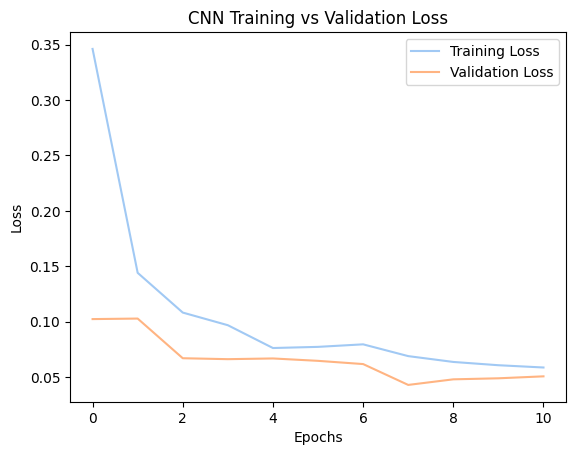

In [ ]:
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CNN Training vs Validation Loss')
plt.legend()
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

num_classes = len(np.unique(y_train_enc))

bilstm_model = Sequential([
    Bidirectional(LSTM(50, return_sequences=True),
                  input_shape=(X_train_cnn.shape[1], 1)),
    Dropout(0.5),
    Bidirectional(LSTM(50)),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])
bilstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
history =  bilstm_model.fit(
    X_train_cnn,
    y_train_enc,
    epochs=500,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
y_prob_bilstm = bilstm_model.predict(X_test_cnn)
y_pred_bilstm = np.argmax(y_prob_bilstm, axis=1)

acc_bilstm  = accuracy_score(y_test_enc, y_pred_bilstm)
prec_bilstm = precision_score(y_test_enc, y_pred_bilstm, average='weighted')
rec_bilstm  = recall_score(y_test_enc, y_pred_bilstm, average='weighted')
f1_bilstm   = f1_score(y_test_enc, y_pred_bilstm, average='weighted')
auc_bilstm  = roc_auc_score(y_test_enc,y_prob_bilstm,multi_class='ovr',average='weighted')
print('BiLSTM')
print(f'Accuracy: {acc_bilstm:.4f}, Precision: {prec_bilstm:.4f}, Recall: {rec_bilstm:.4f}, F1: {f1_bilstm:.4f}, AUC: {auc_bilstm:.4f}')
print(classification_report(y_test_enc, y_pred_bilstm,digits=5))
cm_bilstm = confusion_matrix(y_test_enc, y_pred_bilstm)
print(cm_bilstm)

211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
BiLSTM
Accuracy: 0.9856, Precision: 0.9858, Recall: 0.9856, F1: 0.9856, AUC: 0.9994
              precision    recall  f1-score   support

           0    0.99233   0.96661   0.97930      2276
           1    0.99172   0.99861   0.99515      2159
           2    0.97372   0.99222   0.98288      2315

    accuracy                        0.98563      6750
   macro avg    0.98592   0.98581   0.98578      6750
weighted avg    0.98575   0.98563   0.98560      6750

[[2200   16   60]
 [   1 2156    2]
 [  16    2 2297]]


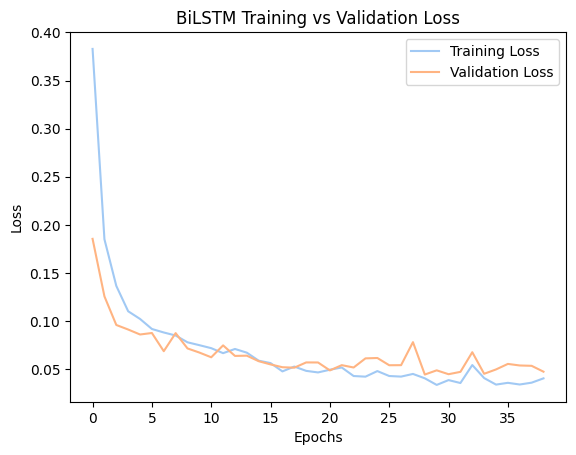

In [ ]:
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('BiLSTM Training vs Validation Loss')
plt.legend()
plt.show()

In [ ]:
auc_bilstm = roc_auc_score(
    y_test_enc,
    y_prob_bilstm,
    multi_class='ovr',
    average='weighted'
)

print(f"AUC (BiLSTM) = {auc_bilstm:.10f}")

AUC (BiLSTM) = 0.9994187249



📊 MODEL COMPARISON TABLE:
    Model  Accuracy  Precision    Recall        F1       AUC  \
0      RF  0.989185   0.989202  0.989185  0.989182  0.999134   
1     XGB  0.996444   0.996445  0.996444  0.996444  0.999919   
2     CNN  0.986074   0.986192  0.986074  0.986062  0.999200   
3  BiLSTM  0.985630   0.985752  0.985630  0.985600  0.999419   

   False Positive Rate (FPR)%  False Negative Rate (FNR)%  
0                    0.542732                    1.070670  
1                    0.179283                    0.350861  
2                    0.702447                    1.375718  
3                    0.723338                    1.418561  

✅ Best Model based on F1-score: XGB


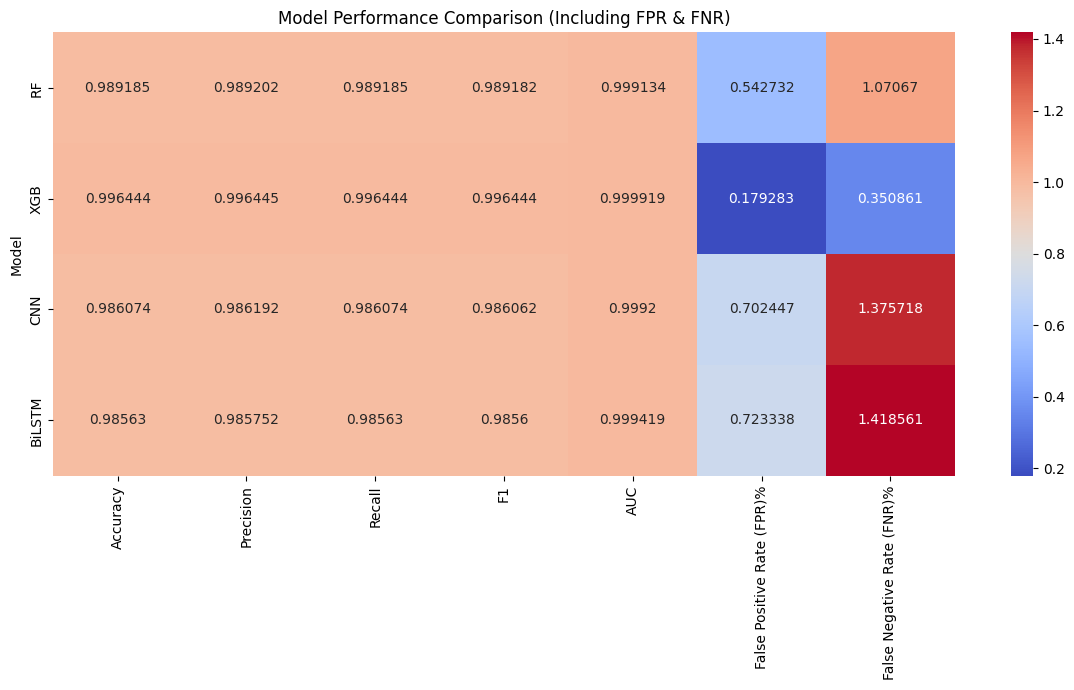

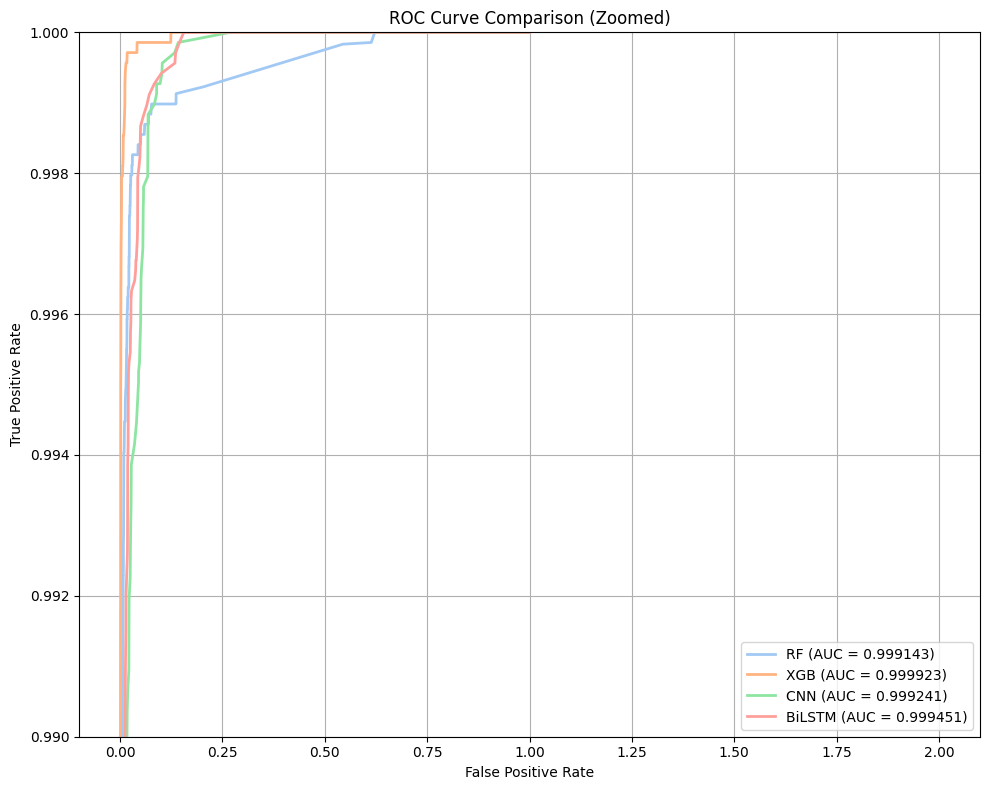

In [ ]:
# ===================== IMPORTS =====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize


# ===================== FP & FN RATE FUNCTION =====================
def compute_fpr_fnr(y_true, y_pred):
    """
    Computes macro-averaged False Positive Rate and False Negative Rate
    (suitable for multiclass problems)
    """
    cm = confusion_matrix(y_true, y_pred)

    FP = cm.sum(axis=0) - np.diag(cm)
    FN = cm.sum(axis=1) - np.diag(cm)
    TP = np.diag(cm)
    TN = cm.sum() - (FP + FN + TP)

    FPR = FP / (FP + TN)
    FNR = FN / (FN + TP)

    return np.mean(FPR)*100, np.mean(FNR)*100


# ===================== FP & FN FOR EACH MODEL =====================
fpr_rf, fnr_rf = compute_fpr_fnr(y_test, y_pred_rf)
fpr_xgb, fnr_xgb = compute_fpr_fnr(y_test_enc, y_pred_xgb)
fpr_cnn, fnr_cnn = compute_fpr_fnr(y_test_enc, y_pred_cnn)
fpr_bilstm, fnr_bilstm = compute_fpr_fnr(y_test_enc, y_pred_bilstm)


# ===================== COMPARISON TABLE =====================
models_summary = pd.DataFrame({
    'Model': ['RF', 'XGB', 'CNN', 'BiLSTM'],
    'Accuracy': [acc_rf, acc_xgb, acc_cnn, acc_bilstm],
    'Precision': [prec_rf, prec_xgb, prec_cnn, prec_bilstm],
    'Recall': [rec_rf, rec_xgb, rec_cnn, rec_bilstm],
    'F1': [f1_rf, f1_xgb, f1_cnn, f1_bilstm],
    'AUC': [auc_rf, auc_xgb, auc_cnn, auc_bilstm],
    'False Positive Rate (FPR)%': [fpr_rf, fpr_xgb, fpr_cnn, fpr_bilstm],
    'False Negative Rate (FNR)%': [fnr_rf, fnr_xgb, fnr_cnn, fnr_bilstm]
})

print("\n📊 MODEL COMPARISON TABLE:")
print(models_summary.round(6))


# ===================== BEST MODEL =====================
best_idx = models_summary['F1'].idxmax()
best_model_name = models_summary.loc[best_idx, 'Model']
print(f"\n Best Model based on F1-score: {best_model_name}")


# ===================== HEATMAP =====================
plt.figure(figsize=(12, 7))
sns.heatmap(
    models_summary.set_index('Model'),
    annot=models_summary.set_index('Model').round(6),
    fmt='',
    cmap='coolwarm'
)
plt.title('Model Performance Comparison (Including FPR & FNR)')
plt.tight_layout()
plt.savefig('model_comparison_heatmap_extended.png', dpi=300)
plt.show()


# ===================== ROC CURVE (ZOOMED) =====================
n_classes = len(np.unique(y_test_enc))
y_test_bin = label_binarize(y_test_enc, classes=range(n_classes))

model_probs = {
    'RF': y_prob_rf,
    'XGB': y_prob_xgb,
    'CNN': y_prob_cnn,
    'BiLSTM': y_prob_bilstm
}

plt.figure(figsize=(10, 8))

for model_name, y_prob in model_probs.items():
    fpr = {}
    tpr = {}

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])

    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)

    plt.plot(
        all_fpr,
        mean_tpr,
        linewidth=2,
        label=f'{model_name} (AUC = {macro_auc:.6f})'
    )

plt.xlim(-0.10, 2.1)
plt.ylim(0.99, 1.0)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (Zoomed)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig('roc_comparison_zoomed.png', dpi=300)
plt.show()


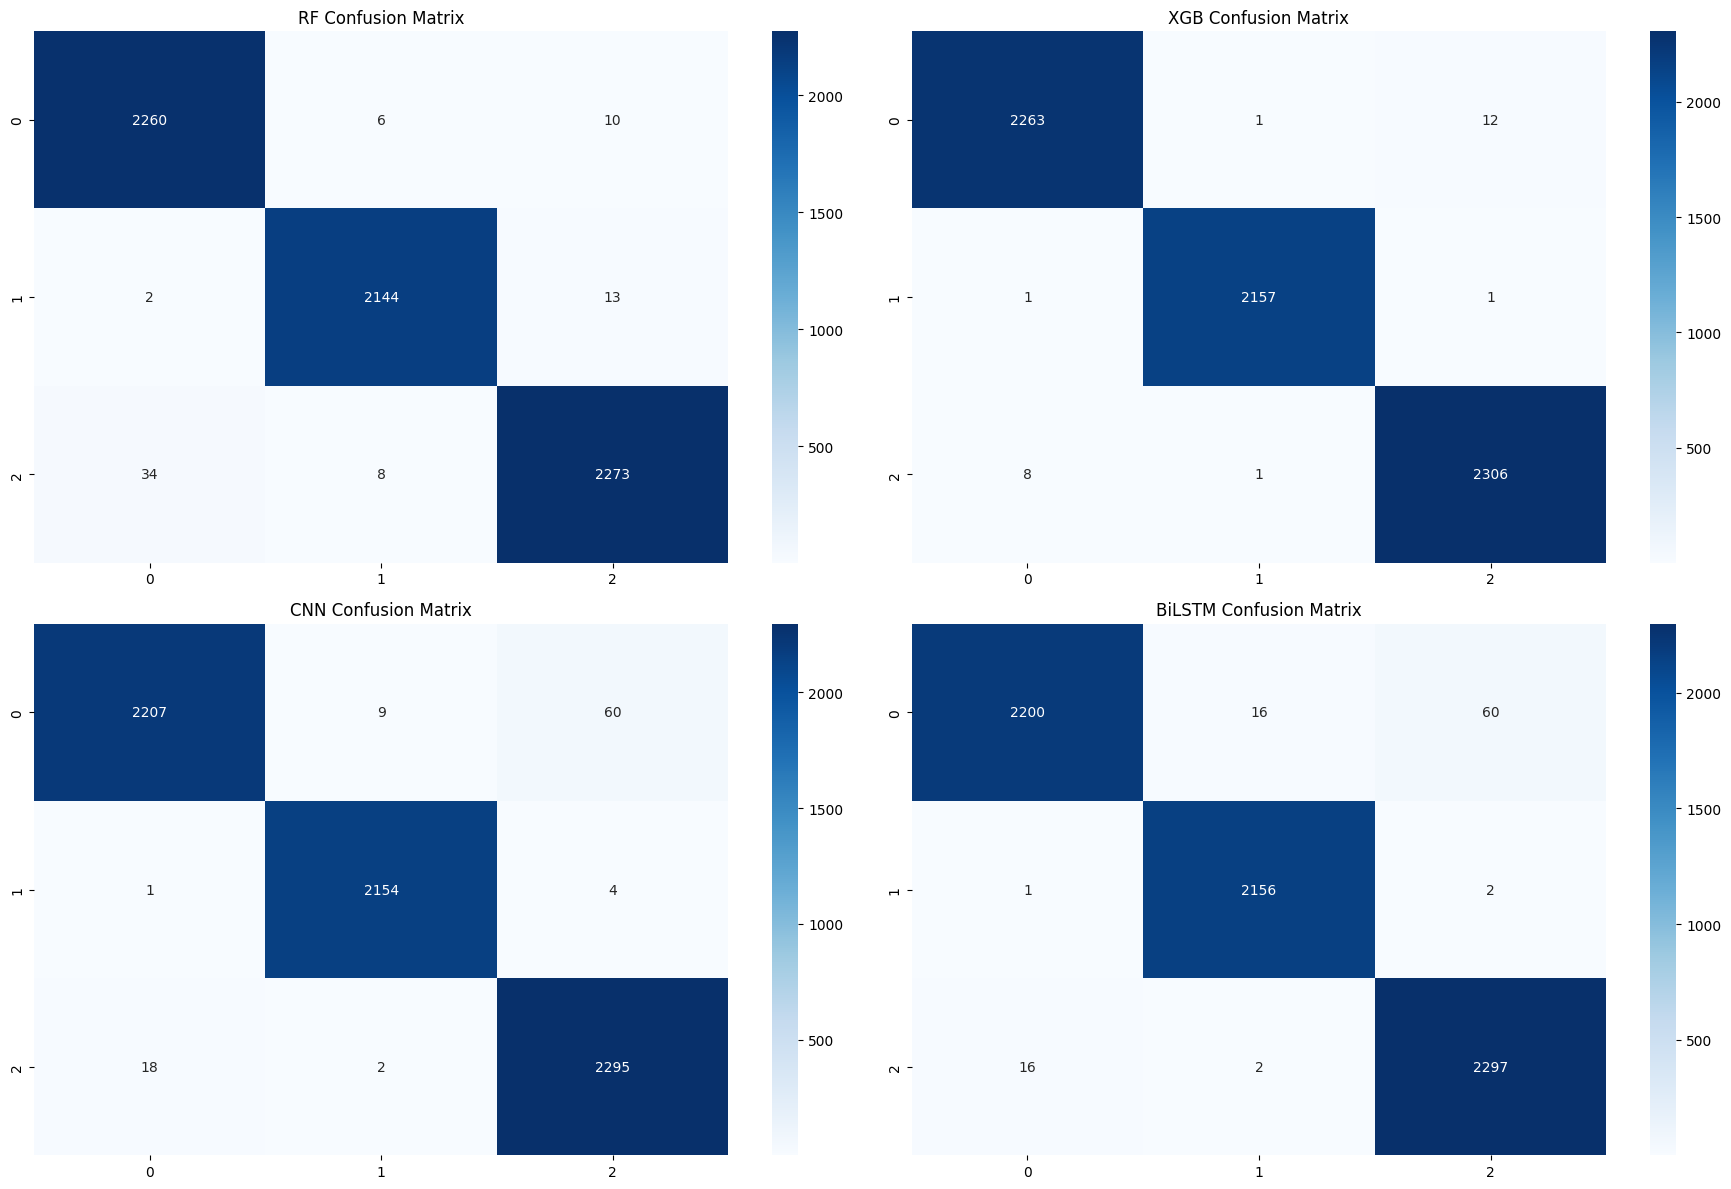

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
cms = {
    'RF': cm_rf,
    'XGB': cm_xgb,
    'CNN': cm_cnn,
    'BiLSTM': cm_bilstm
}
for i, (model, cm) in enumerate(cms.items()):
    row = i // 2
    col = i % 2
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[row, col])
    axes[row, col].set_title(f'{model} Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=300)
plt.show()

In [ ]:
class_counts = data['target'].value_counts()
selected_classes = class_counts[class_counts > 1950]
class_names = selected_classes.index
selected = data[data['target'].isin(class_names)]

dfs1 = []
for name in class_names:
  df1 = selected[selected['target'] == name]
  if len(df1) > 2500:
    df1 = df1.sample(n = 9000, random_state = 0)

  dfs1.append(df1)

df1 = pd.concat(dfs1, ignore_index = True)
df1['target'].value_counts()

,count
target,
0,9000
2,9000
1,9000


In [ ]:
from imblearn.over_sampling import SMOTE

X = df1.drop('target', axis=1)
y = df1['target']

smote = SMOTE(sampling_strategy='auto', random_state=0)
X_upsampled1, y_upsampled1 = smote.fit_resample(X, y)

xaidata = pd.DataFrame(X_upsampled1)
xaidata['target'] = y_upsampled1
xaidata = xaidata.sample(frac=1)

xaidata['target'].value_counts()

,count
target,
1,9000
2,9000
0,9000


In [ ]:
features = xaidata.drop('target', axis = 1)
labels = xaidata['target']

X_train1, X_test1, y_train1, y_test1 = train_test_split(features, labels, test_size = 0.25, random_state = 0)

In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import Dict, List, Tuple, Union, Optional

try:
    import dice_ml
    DICE_AVAILABLE = True
except ImportError:
    DICE_AVAILABLE = False

def get_class_names(y) -> List[str]:
    """
    You should customize this mapping according to your actual labels
    """
    mapping = {
        0: "BENIGN",
        1: "DDoS",
        2: "DoS",
    }
    unique = np.unique(y)
    return [mapping.get(int(v), f"Class {int(v)}") for v in unique]


def prediction_to_label(pred_proba: np.ndarray, class_names: List[str]) -> Dict:
    idx = pred_proba.argmax()
    return {
        "predicted_class": class_names[idx],
        "confidence": float(pred_proba.max()),
        "probabilities": dict(zip(class_names, pred_proba.round(4)))
    }

In [ ]:
def compute_global_shap(
    model,
    X_background: pd.DataFrame,
    X_summary: Optional[pd.DataFrame] = None,
    max_samples: int = 300,
    tree_limit: Optional[int] = None
) -> shap.Explainer:
    """
    Best practice for XGBoost / LightGBM / CatBoost / sklearn trees:
    → TreeExplainer is fast and exact
    """
    try:
        explainer = shap.TreeExplainer(
            model,
            feature_perturbation="tree_path_dependent",
            model_output="raw"
        )
        print("✅ Using fast & accurate TreeExplainer")
    except Exception as e:
        print("TreeExplainer not available → falling back to KernelExplainer", e)
        if X_summary is None:
            X_summary = shap.kmeans(X_background.values, k=min(50, len(X_background))).data
        explainer = shap.KernelExplainer(
            lambda x: model.predict_proba(x) if hasattr(model, "predict_proba") else model.predict(x),
            X_summary,
            link="logit"
        )

    if tree_limit is not None and hasattr(explainer, "model"):
        if hasattr(explainer.model, "limit_trees"):
            explainer.model = explainer.model.limit_trees(tree_limit)

    return explainer

In [ ]:
def plot_global_shap_summary(
    shap_values: Union[shap.Explanation, np.ndarray, list],
    features: pd.DataFrame,
    class_names: List[str] = None,
    max_display: int = 15,
    plot_type: str = "bar"          # "bar" / "dot" / "violin"
):
    plt.figure(figsize=(10, max_display//1.8 + 2))

    if isinstance(shap_values, list):
        shap.summary_plot(
            shap_values,
            features,
            class_names=class_names,
            plot_type=plot_type,
            max_display=max_display,
            show=False
        )
    else:
        shap.summary_plot(
            shap_values,
            features,
            plot_type=plot_type,
            max_display=max_display,
            show=False
        )

    plt.title("Global SHAP Feature Importance")
    plt.tight_layout()
    plt.show()


def global_feature_importance_table(
    shap_values: np.ndarray,
    feature_names: List[str],
    top_n: int = 20
) -> pd.DataFrame:

    if shap_values.ndim == 3: # Multi-class: (samples, features, classes)
        # Average absolute SHAP values across samples and classes
        importance = np.mean(np.abs(shap_values), axis=(0, 2))
    elif shap_values.ndim == 2: # Single output: (samples, features)
        # Average absolute SHAP values across samples
        importance = np.abs(shap_values).mean(axis=0)
    else:
        raise ValueError("Unsupported SHAP values dimension for importance calculation.")

    df = pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": importance.round(4)
    }).sort_values("mean_abs_shap", ascending=False).head(top_n)

    df["rank"] = range(1, len(df)+1)
    df["importance_pct"] = (df["mean_abs_shap"] / df["mean_abs_shap"].sum() * 100).round(2)

    return df

In [ ]:
def explain_single_prediction(
    model,
    explainer: shap.Explainer,
    x_instance: Union[pd.Series, pd.DataFrame, np.ndarray],
    class_names: List[str],
    true_label: Optional[int] = None,
    figsize=(14, 7)
) -> Dict:
    # Normalize input
    if isinstance(x_instance, pd.Series):
        x_instance = x_instance.to_frame().T
    elif isinstance(x_instance, np.ndarray):
        x_instance = pd.DataFrame(x_instance, columns=explainer.feature_names)

    # Predict
    proba = model.predict_proba(x_instance)[0]
    pred_idx = proba.argmax()
    pred_label = class_names[pred_idx]

    # SHAP
    shap_values = explainer(x_instance)

    # Creating a single Explanation object for the predicted class
    shap_values_for_predicted_class = shap.Explanation(
        values=shap_values.values[0, :, pred_idx],  # SHAP values for the predicted class
        base_values=explainer.expected_value[pred_idx], # Base value for the predicted class, correctly indexed from explainer
        data=shap_values.data[0], # Data for the instance
        feature_names=shap_values.feature_names # Feature names
    )

    shap.plots.waterfall(shap_values_for_predicted_class, max_display=12, show=False)
    plt.title(f"Waterfall – Predicted: {pred_label} ({proba.max():.1%})")
    plt.tight_layout()
    plt.show()

    shap.plots.force(shap_values_for_predicted_class, matplotlib=True, show=False)
    plt.title(f"Force Plot – {pred_label}")
    plt.show()

    contributions = shap_values.values[0, :, pred_idx]
    features = x_instance.columns
    values = x_instance.iloc[0]

    pos = [(f, c, v) for f, c, v in zip(features, contributions, values) if c > 0.01]
    neg = [(f, c, v) for f, c, v in zip(features, contributions, values) if c < -0.01]

    pos.sort(key=lambda x: x[1], reverse=True)
    neg.sort(key=lambda x: x[1])

    explanation = {
        "predicted_class": pred_label,
        "confidence": float(proba.max()),
        "true_label": class_names[true_label] if true_label is not None else None,
        "top_positive": [(f"{f} = {v:.3g}", f"+{c:.3f}") for f,c,v in pos[:6]],
        "top_negative": [(f"{f} = {v:.3g}", f"{c:.3f}") for f,c,v in neg[:6]],
    }

    print(f"\nPrediction: {pred_label}  ({proba.max():.1%})")
    if explanation["true_label"]:
        print(f"True label : {explanation['true_label']}\n")

    print("Features that increased attack probability:")
    for feat, contrib in explanation["top_positive"][:5]:
        print(f"  \u2022 {feat:>35}  \u2192  {contrib}")

    print("\nFeatures that decreased attack probability:")
    for feat, contrib in explanation["top_negative"][:5]:
        print(f"  \u2022 {feat:>35}  \u2192  {contrib}")

    return explanation

✅ Using fast & accurate TreeExplainer


/tmp/ipykernel_1489/1727806143.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


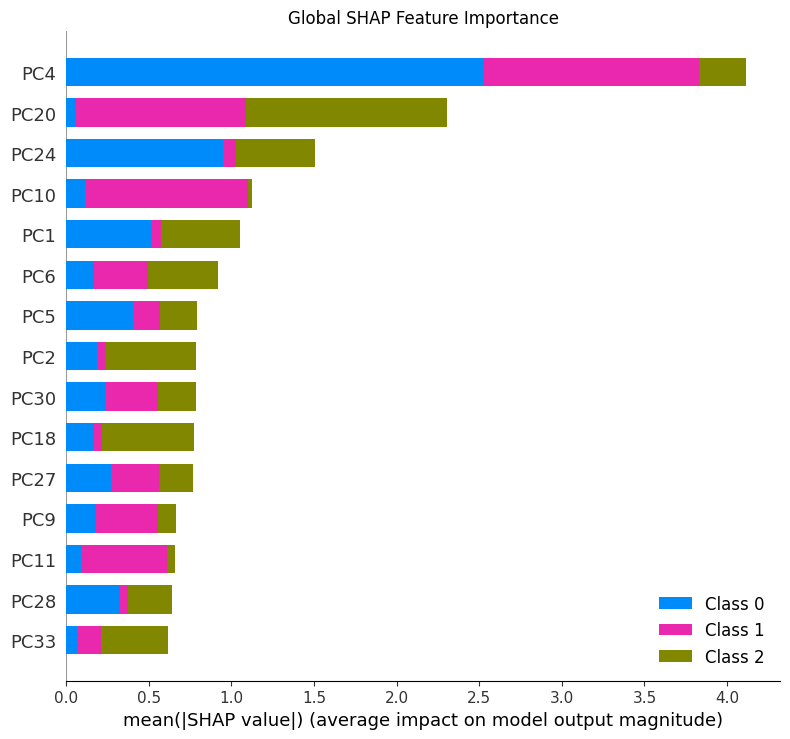

,feature,mean_abs_shap,rank,importance_pct
3,PC4,1.3715,1,23.50
19,PC20,0.7674,2,13.15
23,PC24,0.5017,3,8.60
9,PC10,0.3743,4,6.41
0,PC1,0.3506,5,6.01
5,PC6,0.3068,6,5.26
4,PC5,0.2646,7,4.53
1,PC2,0.2626,8,4.50
29,PC30,0.2624,9,4.50
17,PC18,0.2585,10,4.43


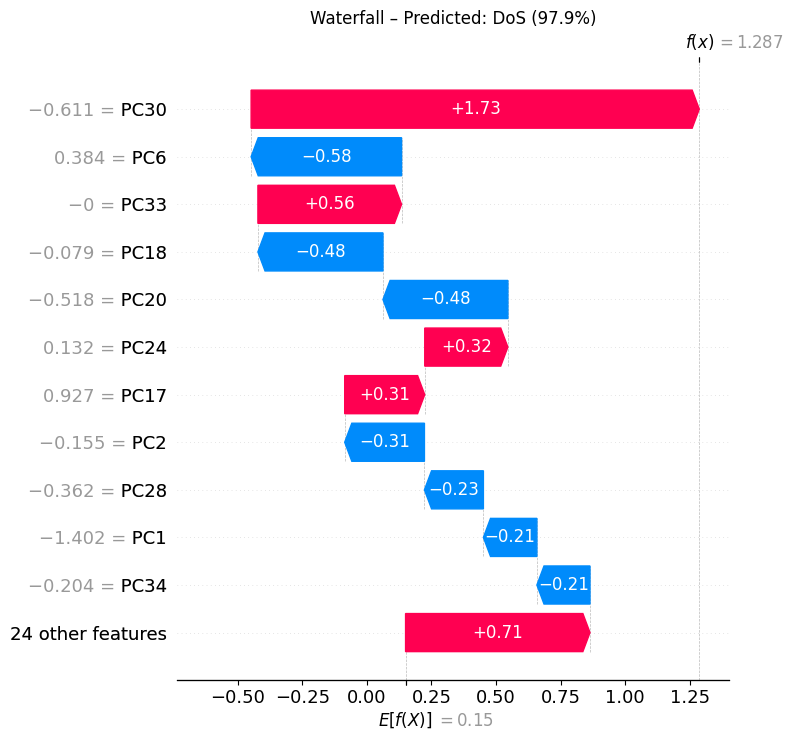

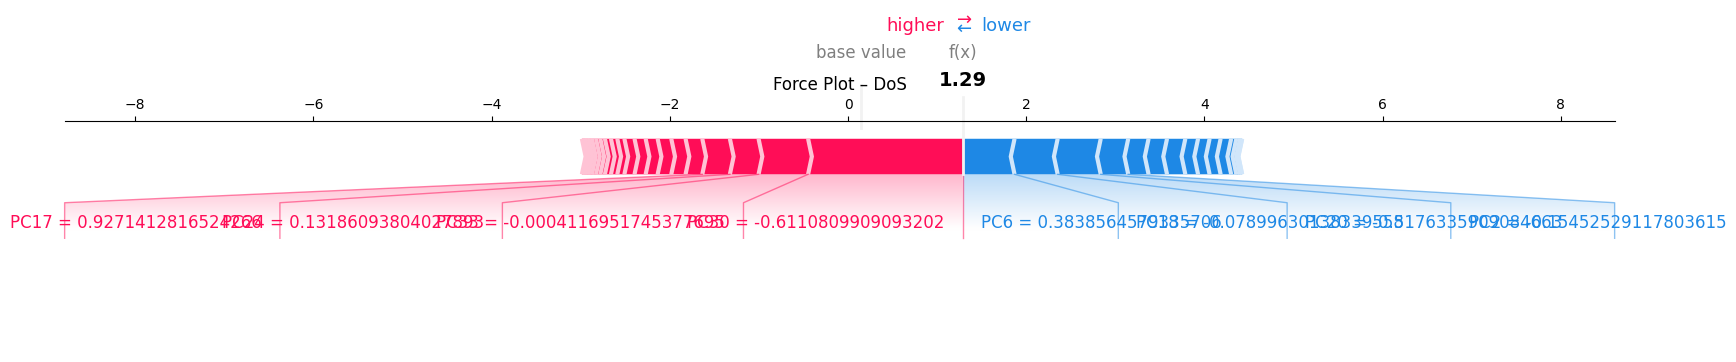


Prediction: DoS  (97.9%)
True label : DoS

Features that increased attack probability:
  •                       PC30 = -0.611  →  +1.735
  •                    PC33 = -0.000412  →  +0.556
  •                        PC24 = 0.132  →  +0.322
  •                        PC17 = 0.927  →  +0.310
  •                        PC9 = -0.634  →  +0.188

Features that decreased attack probability:
  •                         PC6 = 0.384  →  -0.582
  •                       PC18 = -0.079  →  -0.484
  •                       PC20 = -0.518  →  -0.483
  •                        PC2 = -0.155  →  -0.309
  •                       PC28 = -0.362  →  -0.228


{'predicted_class': 'DoS',
 'confidence': 0.9788224101066589,
 'true_label': 'DoS',
 'top_positive': [('PC30 = -0.611', '+1.735'),
  ('PC33 = -0.000412', '+0.556'),
  ('PC24 = 0.132', '+0.322'),
  ('PC17 = 0.927', '+0.310'),
  ('PC9 = -0.634', '+0.188'),
  ('PC16 = -0.0945', '+0.160')],
 'top_negative': [('PC6 = 0.384', '-0.582'),
  ('PC18 = -0.079', '-0.484'),
  ('PC20 = -0.518', '-0.483'),
  ('PC2 = -0.155', '-0.309'),
  ('PC28 = -0.362', '-0.228'),
  ('PC1 = -1.4', '-0.207')]}

In [ ]:

model          = xgb
# X_train        = training features (pandas DataFrame)
# X_test         = test features
# y_train, y_test

class_names = get_class_names(y_train_enc)

background = X_train.sample(200, random_state=42)

explainer = compute_global_shap(model, background)

# Global importance
shap_values_global = explainer(background)

plot_global_shap_summary(shap_values_global, background, class_names)
display(global_feature_importance_table(shap_values_global.values, X_train.columns, top_n=15))

# Explain one example
idx = 42
x_example = pd.DataFrame(X_test).iloc[[idx]]
true_y = y_test_enc[idx]

explain_single_prediction(
    model,
    explainer,
    x_example,
    class_names,
    true_label=true_y
)

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

class SHAPExplainer:
    def __init__(self, model, X_train, model_type="auto"):
        self.model = model
        self.X_train = X_train

        self.explainer = shap.TreeExplainer(model)

        self.shap_values = self.explainer(X_train)

    def summary_plot(self):
        shap.plots.beeswarm(self.shap_values)
        plt.show()

    def summary_bar(self):
        shap.plots.bar(self.shap_values)
        plt.show()

    def dependence_plot(self, feature_name):
        shap.plots.scatter(
            self.shap_values[:, feature_name],
            color=self.shap_values
        )
        plt.show()

    def interaction_heatmap(self):
        interaction_values = self.explainer.shap_interaction_values(self.X_train)

        if isinstance(interaction_values, list):
            interaction_values = interaction_values[0]

        shap.summary_plot(interaction_values, self.X_train)
        plt.show()

In [ ]:
class LocalSHAPExplainer:
    def __init__(self, model, X_train):
        self.model = model
        self.explainer = shap.TreeExplainer(model)
        self.X_train = X_train

    def explain_instance(self, instance):
        shap_values = self.explainer(instance)

        shap.plots.force(shap_values[0], matplotlib=True)
        plt.show()

        shap.plots.waterfall(shap_values[0])
        plt.show()

        contributions = shap_values.values[0]

        contribution_df = (
            pd.DataFrame({
                "Feature": instance.columns,
                "Contribution": contributions
            })
            .sort_values("Contribution", key=abs, ascending=False)
        )

        return contribution_df

In [ ]:
class InteractionExplainer:
    def __init__(self, model, X_train):
        self.model = model
        self.X_train = X_train
        self.explainer = shap.TreeExplainer(model)

    def interaction_values(self):
        interaction_values = self.explainer.shap_interaction_values(self.X_train)
        return interaction_values

    def interaction_summary(self):
        shap.summary_plot(
            self.explainer.shap_interaction_values(self.X_train),
            self.X_train
        )

In [ ]:
!pip install dice-ml

import dice_ml
from dice_ml import Dice

class CounterfactualExplainer:
    def __init__(self, model, X_train, target_name):
        data = dice_ml.Data(
            dataframe=X_train,
            continuous_features=X_train.columns.tolist(),
            outcome_name=target_name
        )

        model_dice = dice_ml.Model(model=model, backend="sklearn")

        self.exp = Dice(data, model_dice)

    def generate(self, instance):
        cf = self.exp.generate_counterfactuals(
            instance,
            total_CFs=3,
            desired_class="opposite"
        )
        return cf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 29.6 MB/s eta 0:00:00


In [ ]:
def group_shap_analysis(shap_values, X, sensitive_feature):
    df = pd.DataFrame(shap_values, columns=X.columns)
    df[sensitive_feature] = X[sensitive_feature].values

    group_means = df.groupby(sensitive_feature).mean()
    return group_means

In [ ]:
class RealTimeExplainer:
    def __init__(self, model, X_train):
        self.model = model
        self.explainer = shap.TreeExplainer(model)
        self.X_train = X_train

    def explain_prediction(self, input_data):
        prediction = self.model.predict(input_data)[0]
        shap_values = self.explainer.shap_values(input_data)

        contribution_df = pd.DataFrame({
            "feature": input_data.columns,
            "contribution": shap_values[0]
        }).sort_values("contribution", key=abs, ascending=False)

        explanation = f"""
        Prediction: {prediction}

        Top contributing features:
        {contribution_df.head(5).to_string(index=False)}
        """

        return {
            "prediction": prediction,
            "shap_values": shap_values,
            "contributions": contribution_df,
            "explanation": explanation
        }

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)

In [ ]:
shap_vals_attack = shap_values[:, :, 1]   # Class 1 = DDoS

/tmp/ipykernel_1489/1222043226.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals_attack, X_train)


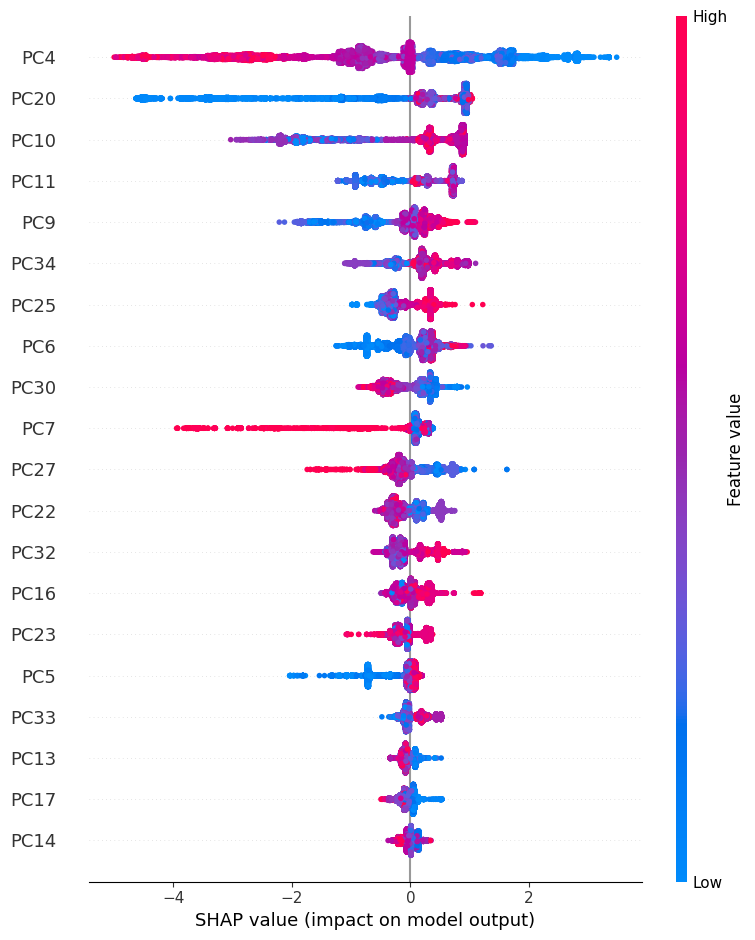

In [ ]:
shap.summary_plot(shap_vals_attack, X_train)

/tmp/ipykernel_1489/1222043226.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals_attack, X_train)


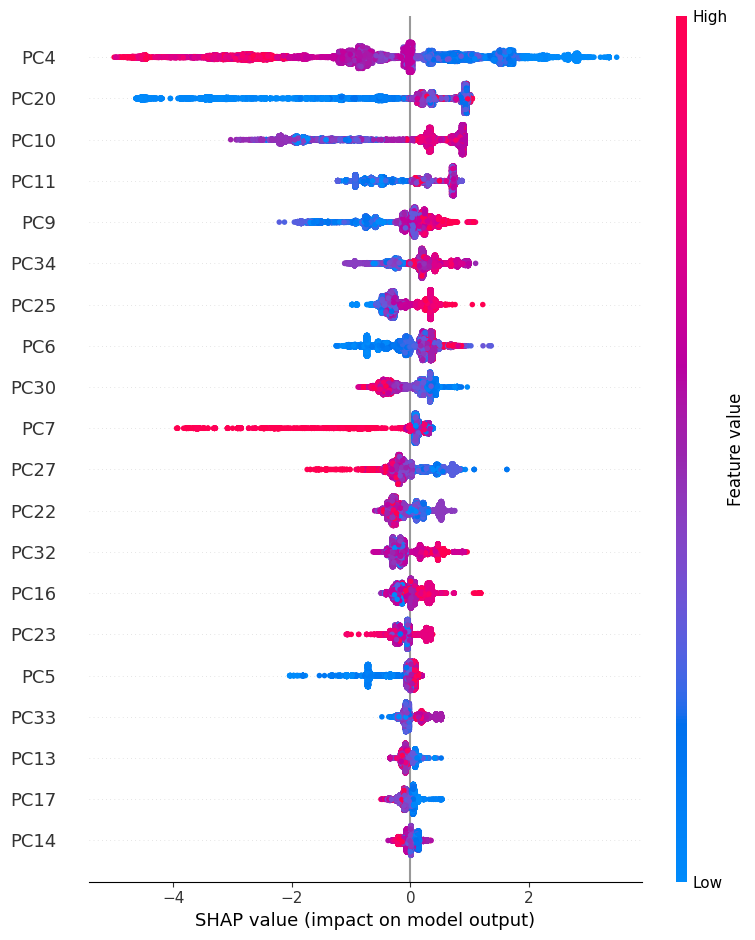

In [ ]:
shap.summary_plot(shap_vals_attack, X_train)

In [ ]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "mean_abs_shap": np.abs(shap_vals_attack).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

print(importance_df.head(15))

   feature  mean_abs_shap
3      PC4       1.342328
19    PC20       1.096238
9     PC10       0.984118
10    PC11       0.530665
8      PC9       0.380911
33    PC34       0.348754
24    PC25       0.330967
5      PC6       0.324997
29    PC30       0.314812
6      PC7       0.282621
26    PC27       0.281129
21    PC22       0.249294
31    PC32       0.245266
15    PC16       0.177564
22    PC23       0.175904


In [ ]:
comparison = pd.DataFrame({
    "feature": X_train.columns,
    "model_importance": model.feature_importances_,
    "shap_importance": np.abs(shap_vals_attack).mean(axis=0)
}).sort_values("shap_importance", ascending=False)

print(comparison.head(15))

   feature  model_importance  shap_importance
3      PC4          0.087844         1.342328
19    PC20          0.217248         1.096238
9     PC10          0.034772         0.984118
10    PC11          0.172956         0.530665
8      PC9          0.038965         0.380911
33    PC34          0.005286         0.348754
24    PC25          0.003259         0.330967
5      PC6          0.005638         0.324997
29    PC30          0.011774         0.314812
6      PC7          0.078246         0.282621
26    PC27          0.009912         0.281129
21    PC22          0.003463         0.249294
31    PC32          0.005587         0.245266
15    PC16          0.003210         0.177564
22    PC23          0.004444         0.175904


In [ ]:
top_ratio = importance_df.iloc[0]["mean_abs_shap"] / importance_df["mean_abs_shap"].sum()

if top_ratio > 0.5:
    print("⚠️ Model overly depends on single network feature.")
else:
    print("Model decisions distributed across traffic features.")

Model decisions distributed across traffic features.


LOCAL EXPLANATION (Single Network Flow

In [ ]:
instance = X_test.iloc[[10]]

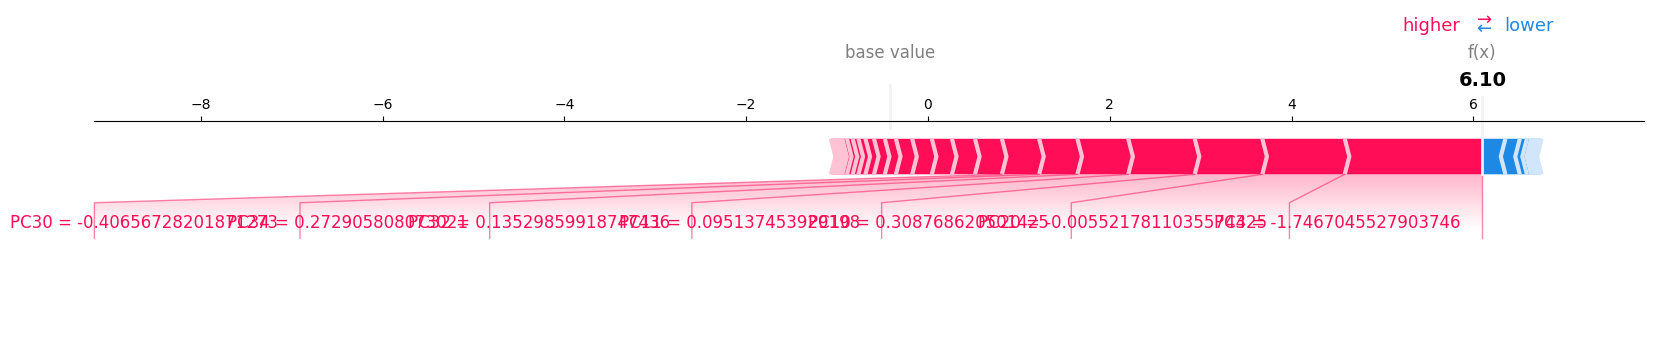

In [ ]:
# Get the Explanation object for the single instance
shap_explanation_for_instance = explainer(instance)

# Extract the base value for class 1 (DDoS)
base_value_class1 = explainer.expected_value[1]

shap_values_class1 = shap_explanation_for_instance.values[0, :, 1]

shap.force_plot(
    base_value_class1,
    shap_values_class1,
    instance,
    matplotlib=True
)

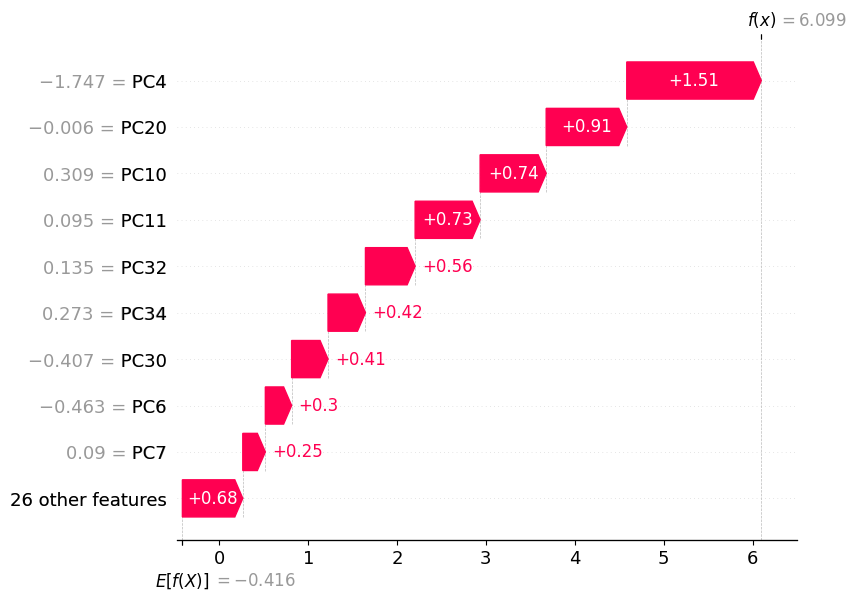

In [ ]:
shap.waterfall_plot(
    shap.Explanation(
        values=explainer.shap_values(instance)[0, :, 1],
        base_values=explainer.expected_value[1],
        data=instance.iloc[0],
        feature_names=X_train.columns
    )
)

In [ ]:
# Assuming 'explainer' and 'instance' are defined from previous cells.

shap_explanation = explainer(instance) # Get the shap.Explanation object for the single instance

# Extract SHAP values for class 1 (DDoS) for this single instance
# shap_explanation.values is of shape (1, num_features, num_classes)
# We want values for the first sample (index 0), all features (all :), and class 1 (index 1)
local_shap = shap_explanation.values[0, :, 1]

contrib_df = pd.DataFrame({
    "feature": X_train.columns,
    "contribution": local_shap
}).sort_values("contribution", key=abs, ascending=False)

print(contrib_df.head(10))

   feature  contribution
3      PC4      1.513840
19    PC20      0.906839
9     PC10      0.743417
10    PC11      0.731367
31    PC32      0.559234
33    PC34      0.421044
29    PC30      0.409797
5      PC6      0.295687
6      PC7      0.253829
24    PC25     -0.253151


In [ ]:
import xgboost as xgb
import pandas as pd
import json

def xgb_decision_path(model, instance, tree_index=0):
    """
    Extract decision rules from one XGBoost tree
    """

    booster = model.get_booster()
    dump = booster.get_dump(dump_format='json')

    tree = json.loads(dump[tree_index])

    rules = []

    def traverse(node, instance):
        if "leaf" in node:
            return

        feature = node["split"]
        threshold = node["split_condition"]
        value = instance[feature].values[0]

        if value < threshold:
            rules.append(f"{feature} < {threshold}")
            traverse(node["children"][0], instance)
        else:
            rules.append(f"{feature} >= {threshold}")
            traverse(node["children"][1], instance)

    traverse(tree, instance)

    return rules

In [ ]:
instance = X_test.iloc[[10]]

rules = xgb_decision_path(model, instance)

for r in rules:
    print(r)

PC1 >= -1.98974597
PC4 < -0.307412475
PC5 >= -0.962091148
PC29 < 0.432920218
PC9 >= -1.26386929
PC1 >= -1.94079566


In [ ]:
import dice_ml
from dice_ml import Dice

df_train = X_train.copy()
df_train["Label"] = y_train

data_dice = dice_ml.Data(
    dataframe=df_train,
    continuous_features=X_train.columns.tolist(),
    outcome_name="Label"
)

model_dice = dice_ml.Model(model=model, backend="sklearn")
dice_exp = Dice(data_dice, model_dice)

In [ ]:
cf = dice_exp.generate_counterfactuals(
    instance,
    total_CFs=3,
    desired_class=0 # Changed from "opposite" to a specific class label (0 for BENIGN)
)

cf.visualize_as_dataframe()

100%|██████████| 1/1 [00:00<00:00,  1.52it/s]

Query instance (original outcome : 1)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35,Label
0,2.742288,0.328918,-5.148322,-1.746705,-0.656961,-0.463343,0.090293,2.387048,0.288533,0.308769,...,-0.109579,0.740325,-0.066656,-0.406567,1.391251,0.135299,-0.000825,0.272906,-0.052735,1



Diverse Counterfactual set (new outcome: 0)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35,Label
0,2.742288,0.328918,-5.148322,23.446302,-0.656961,-0.463343,0.090293,2.387048,0.288533,0.308769,...,-0.109579,0.740325,-0.066656,-0.406567,1.391251,0.135299,-0.000825,0.272906,-0.052735,0
1,2.742288,0.328918,-5.148322,29.614040,-0.656961,-0.463343,0.090293,2.387048,0.288533,0.308769,...,-0.109579,0.740325,-0.066656,-0.406567,1.391251,0.135299,-7.364700,0.272906,-0.052735,0
2,2.742288,0.328918,-5.148322,17.442125,-0.656961,-0.463343,0.090293,2.387048,0.288533,0.308769,...,-0.109579,0.740325,-0.066656,-0.406567,1.391251,0.135299,-0.000825,0.272906,-0.052735,0


In [ ]:
def explain_prediction(input_data):
    prediction = model.predict(input_data)[0]
    shap_explanation = explainer(input_data)
    shap_vals = shap_explanation.values[0, :, 1]

    contrib_df = pd.DataFrame({
        "feature": X_train.columns,
        "contribution": shap_vals
    }).sort_values("contribution", key=abs, ascending=False)

    explanation = f"""
    Prediction: {'ATTACK' if prediction == 1 else 'BENIGN'}

    Top driving network features:
    {contrib_df.head(5).to_string(index=False)}
    """

    return {
        "prediction": prediction,
        "contributions": contrib_df,
        "explanation": explanation
    }

In [ ]:
result = explain_prediction(instance)
print(result["explanation"])


    Prediction: ATTACK

    Top driving network features:
    feature  contribution
    PC4      1.513840
   PC20      0.906839
   PC10      0.743417
   PC11      0.731367
   PC32      0.559234
    
